# **31 · P6-B figure export — 노트북의 그림이 그대로 보고서의 그림이 되는가 (입증)**

### **"F3~F6 4종을 `src/export_figures.py` 하나로 재생성 — 원천 노트북(23·24·03·04)과 같은 src 함수·같은 데이터에서 나왔고, 그림이 담는 수치가 SSOT 인용 상수와 어긋나지 않음을 assert로 박제한다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = 논문형 PDF figure 4종(**F3** 정렬추세 · **F4** APC · **F5** NCHI · **F6** 페르소나) · 방법 = **thin import 실행 + SSOT drift 검증** (새 분석 없음)

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가 이후 — 보고·전개** · CRISP-DM **P6(Deployment — 논문형 PDF 조판 직전 단계)** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 보고서(`dist/report.pdf`)에 실리는 F3~F6은 **재현 가능한 산출**인가 — 스크립트 실행 한 번으로 4종이 실제로 재생성되는가?
> **Q2.** 재생성된 각 figure가 표시하는 핵심 수치(α̂ 7개년 · 기간효과 상관 r · NCHI 방향 · 페르소나 TV 편중)는 **SSOT 인용 상수·원천 노트북 수치와 drift 없이 일치**하는가?
> **Q3.** 왜 원천 노트북에 `savefig` 셀을 넣지 않고 **별도 export 스크립트**로 분리했으며, "같은 그림"이라는 검증은 무엇으로 하는가 — **Decision Box ①·②**.

## **이 노트북의 위상 — 새 분석을 만들지 않는다**

`23`·`24`·`03`·`04`가 분석(그림 원본)을 만들었고 `30`이 결론의 자격을 판정했다면, 31은 **아무것도 새로 분석하지 않는다**. P6-A 설계([`p6-pdf-structure.md`](../docs/report/p6-pdf-structure.md) §2 선정표)가 "export 필요"로 지정한 노트북 인라인 figure 4종이 로직 재구현 없이(thin import) 보고서용 PNG로 이식되었음을 **실행으로 입증**하고, 각 그림이 담는 수치를 §6 검증 셀에서 SSOT와 대조한다.

- **로직 SSOT(thin import)**: [`src/export_figures.py`](../src/export_figures.py) — exporter 4종. 원천 노트북과 **같은 src 모듈**(`alignment`·`trend_apc`·`health_index_panel`·`news_health_features`)을 호출해 동일 계산을 다시 수행한다. 재구현 금지.
- **검증 SSOT**: [`src/p5_evaluation.py`](../src/p5_evaluation.py) 인용 상수(`ALIGN_ALPHA`·`PERIOD_HAPC`·`PERIOD_IE`·`CRED_MEAN`). `30` §6이 "상수 ↔ 출처 문서" drift를 이미 검증했으므로, 여기서 "**figure ↔ 상수**"만 확인하면 **문서 ↔ 상수 ↔ 보고서 그림**의 검증 사슬이 닫힌다.
- **표기 규율**: F3·F4의 SD 단위 수치는 모형 의존(⚠️ 방향만) — 축·캡션에만 두고 본문 헤드라인 인용 금지. F5·F6의 NCHI·구성비 절대값은 formative 설계 의존 — 방향성만(`p6-pdf-structure` §3.5).

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 왜 별도 export 스크립트인가 — **Decision Box ①** | — |
| 2 | [실행] F3 정렬법 잠재평균 추세 (`23` §4) + [시각화] | `assets/fig3_alignment_trend.png` |
| 3 | [실행] F4 APC 3효과 프로파일 (`24` §6) + [시각화] | `assets/fig4_apc_profile.png` |
| 4 | [실행] F5 NCHI 추세·페르소나 구성비 (`03` §3·§4) + [시각화] | `assets/fig5_nchi_trend.png` |
| 5 | [실행] F6 페르소나 × 매체 히트맵 (`04` §5) + [시각화] | `assets/fig6_personas.png` |
| 6 | [입증] 검증 셀 — figure 수치 ↔ SSOT 상수 drift 없음 + **Decision Box ②** | assert PASS |
| 7 | 종합 — 연구질문 답·P6-B-3 조판으로 | — |

In [1]:
import io, re, sys, time
from contextlib import redirect_stdout
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
while not (ROOT / "src" / "export_figures.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import export_figures as X          # SSOT — export 로직(재구현 금지)
import p5_evaluation as P           # 인용 상수 — §6 drift 대조용
import trend_apc as T               # 정렬 점추정 재계산(§6 (a), thin)
import health_index_panel as hp     # NCHI 재계산(§6 (c), thin)
import news_health_features as nf   # 공통 수학(§6 (d), thin)

X._setup_korean_font()
T0 = time.time()                    # §6 (e) — 파일이 '이번 실행'에서 재생성됐는지 판별 기준
panel = X.load_panel()              # 행수 게이트(90,996) 내장 assert
print(f"패널 {len(panel):,}행 · 연도 {sorted(int(y) for y in panel['year'].unique())}")
print(f"export 대상: {list(X.EXPORTERS)} → {X.ASSETS.relative_to(ROOT)}/ (dpi={X.DPI}, bbox_inches='tight')")
print(f"인용 상수 로드 — ALIGN_ALPHA {len(P.ALIGN_ALPHA)}개년 · PERIOD_HAPC/IE {len(P.PERIOD_HAPC)}/{len(P.PERIOD_IE)}개년 · CRED_MEAN {len(P.CRED_MEAN)}개년")

패널 90,996행 · 연도 [2019, 2020, 2021, 2022, 2023, 2024, 2025]
export 대상: ['fig3', 'fig4', 'fig5', 'fig6'] → assets/ (dpi=200, bbox_inches='tight')
인용 상수 로드 — ALIGN_ALPHA 7개년 · PERIOD_HAPC/IE 7/7개년 · CRED_MEAN 7개년


## **1. [전제] 왜 별도 export 스크립트인가 — 노트북에 `savefig` 셀을 넣지 않는 이유**

B트랙 노트북은 실행 출력(표·PASS·figure)을 **박은 채 커밋**하는 정책이다(README). 이 정책 아래에서 "보고서용 PNG 저장"이라는 부수효과를 어디에 둘 것인가가 P6-A의 설계 결정이었다(`p6-pdf-structure.md` §2 export 규칙).

### **Decision Box ① — figure export 방식: 왜 별도 스크립트인가**

**기준: 보고서 그림 4종을 어떻게 만들어야 재현 가능하고, 노트북을 오염시키지 않는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 원천 노트북마다 `savefig` 셀 추가 | `23`·`24`·`03`·`04`에 저장 셀 삽입 | ❌ 그림 하나 바꿀 때마다 노트북 4개 재실행(부트스트랩 포함) → 실행 출력 diff 오염·셀 순서 의존. 저장 규칙(dpi·경로)이 4곳에 분산 |
| (b) 노트북 출력 이미지를 수동 추출 | 커밋된 출력에서 PNG 긁어내기 | ❌ 해상도(dpi)가 인라인 기본값에 묶이고, 재현 절차가 "사람 손"이 됨 — 원고 개정 때마다 수작업 반복 |
| (c) **별도 export 스크립트** | `src/export_figures.py`가 원천과 같은 src 함수를 호출해 일괄 재계산·저장 | ✅ **채택** — `python src/export_figures.py` 한 명령으로 4종 재현, dpi=200 규칙 중앙화, 노트북 무변경. 단 "노트북과 같은 그림인가"는 별도 입증 필요 → **그 입증이 본 노트북(§2~§6)** |

**이 선의 효과**: 원고(manuscript)가 참조하는 `assets/fig*.png`의 재현 경로가 코드 한 줄로 고정되고, 그림의 정합성 책임은 §6 검증 셀(수치 drift 대조)이 진다.

## **2. [실행] F3 — 정렬법 잠재평균 추세 (`23` §4 → `assets/fig3_alignment_trend.png`)**

보고서 4장(결과 I)의 중심 그림. `23`의 주모형(credibility 핵심 3지표 · 연도균등 가중 · 부트스트랩 B=200)을 **그대로 다시 실행**해 α̂ ± 95% CI 추세를 저장한다. 2019→2020 구간 음영은 "첫 스텝 의존성" 주의(23 DB③)의 시각 표기다. 아래 셀은 부트스트랩 재추정을 포함하므로 **수 분** 걸린다 — 이 비용이 곧 "그림이 저장본 재탕이 아니라 재계산 산출"이라는 입증이다.

[F3] 정렬법 주모형 실행(부트스트랩 B=200 — 수 분 소요)…



===== 정렬법 — 주모형: 3지표·연도균등(2019~2025) (G=7, items=3, weight=yeareq) =====
  2019: α=+0.000 (SE 0.000), ψ=1.000, N=5,040
  2020: α=+0.354 (SE 0.025), ψ=1.070, N=5,010
  2021: α=+0.474 (SE 0.030), ψ=1.033, N=5,010
  2022: α=+0.453 (SE 0.020), ψ=1.216, N=58,936
  2023: α=+0.394 (SE 0.028), ψ=1.143, N=5,000
  2024: α=+0.298 (SE 0.027), ψ=1.033, N=6,000
  2025: α=+0.671 (SE 0.028), ψ=0.808, N=6,000
  비동등 비율 = 2.4% (1/42)  [≤20% → alignment-adjusted 평균비교 정당]


  → 저장: assets\fig3_alignment_trend.png (109 KB)


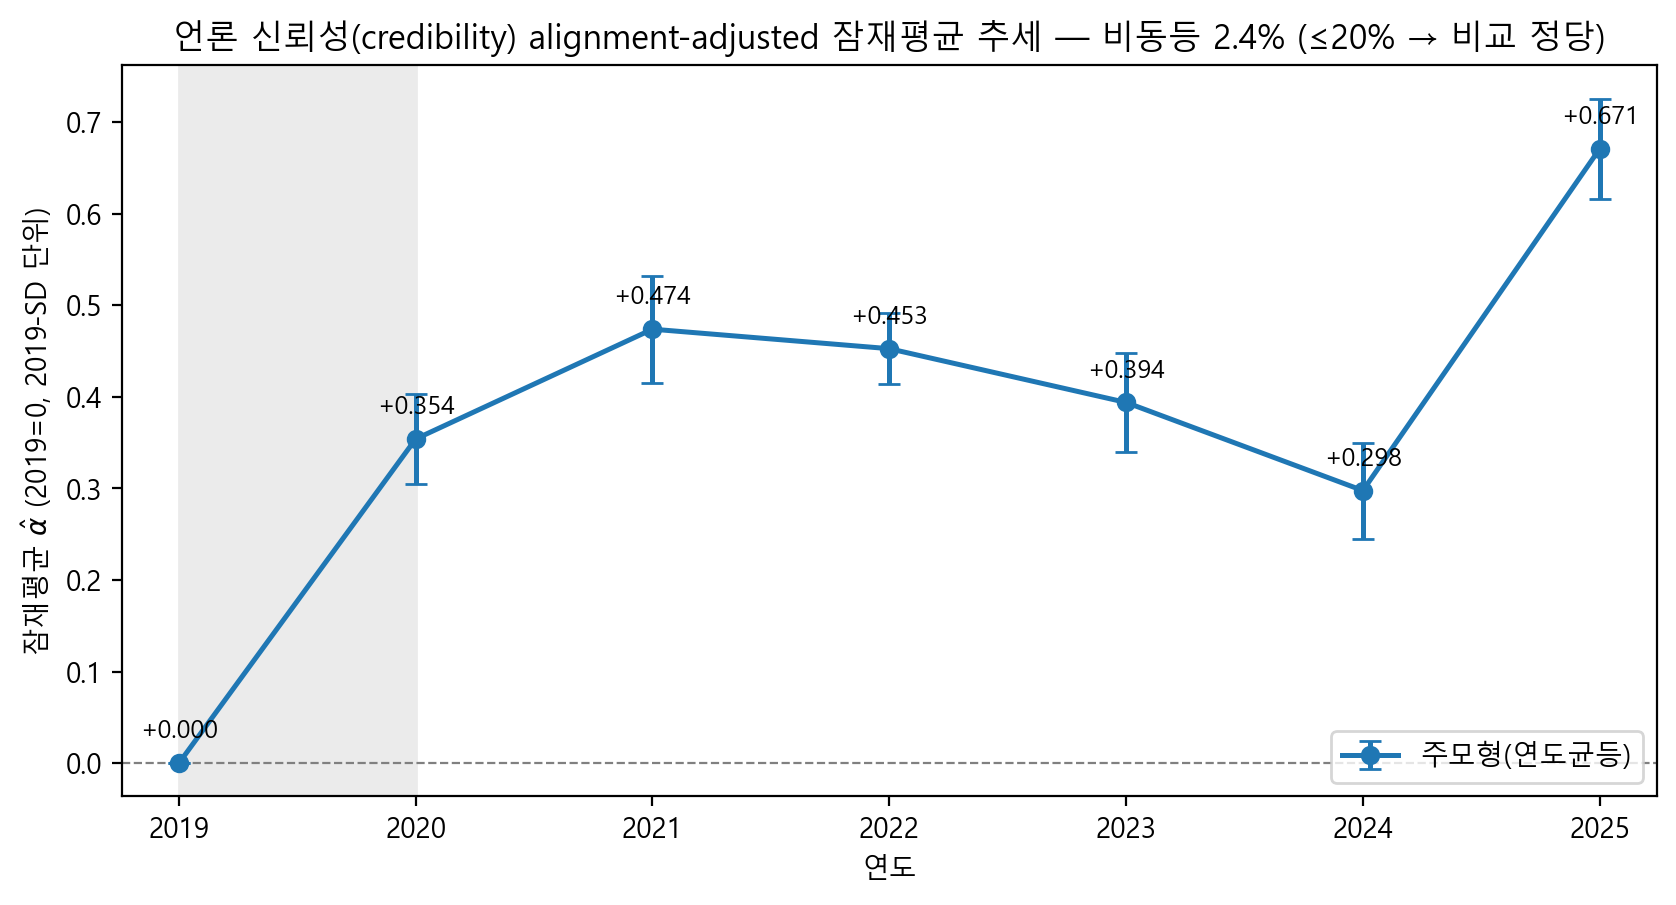

In [2]:
out3 = X.export_fig3(panel)      # 주모형 재실행(부트스트랩 B=200)
display(Image(str(out3), width=940))

**[시각화] 정렬 잠재평균 추세** — 점: 연도별 α̂(2019=0, 2019-SD 단위, 모형 의존 ⚠️), 수직선: 95% CI(부트스트랩), 음영: 2019→2020 첫 스텝, 제목: 비동등 비율(≤20% → 비교 정당).

**관찰**: 2019 이후 전 연도 CI가 0을 상회하고, 궤적은 비단조(2021 고점 → 2024 저점 → 2025 반등)다 — 보고서 4.2절의 서술과 그림이 같은 산출에서 나온다. 축 라벨의 "2019-SD 단위" 명기는 §3.5 표기 규율(본문 헤드라인 인용 금지)의 이식이다.

## **3. [실행] F4 — APC 3효과 프로파일 (`24` §6 → `assets/fig4_apc_profile.png`)**

보고서 4.4절(상승은 '시대'의 효과)·독립 발견(코호트 구배)의 그림. HAPC-GLMM과 IE(내재적 추정량)를 **다시 적합**해 기간·연령·코호트 3효과를 그린다. 실행 로그가 출력하는 기간효과 상관(HAPC-정렬 · IE-정렬)은 그림 (1)패널 범례에 박히는 값과 동일하며, §6 (b)에서 SSOT 상수로 재계산한 상관과 대조한다 — 로그를 `StringIO`로 캡처해 두는 이유다.

[F4] 정렬 점추정 + HAPC-GLMM + IE 실행…
  기간효과 상관: HAPC-정렬 = +0.990 · IE-정렬 = +0.960
  → 저장: assets\fig4_apc_profile.png (172 KB)


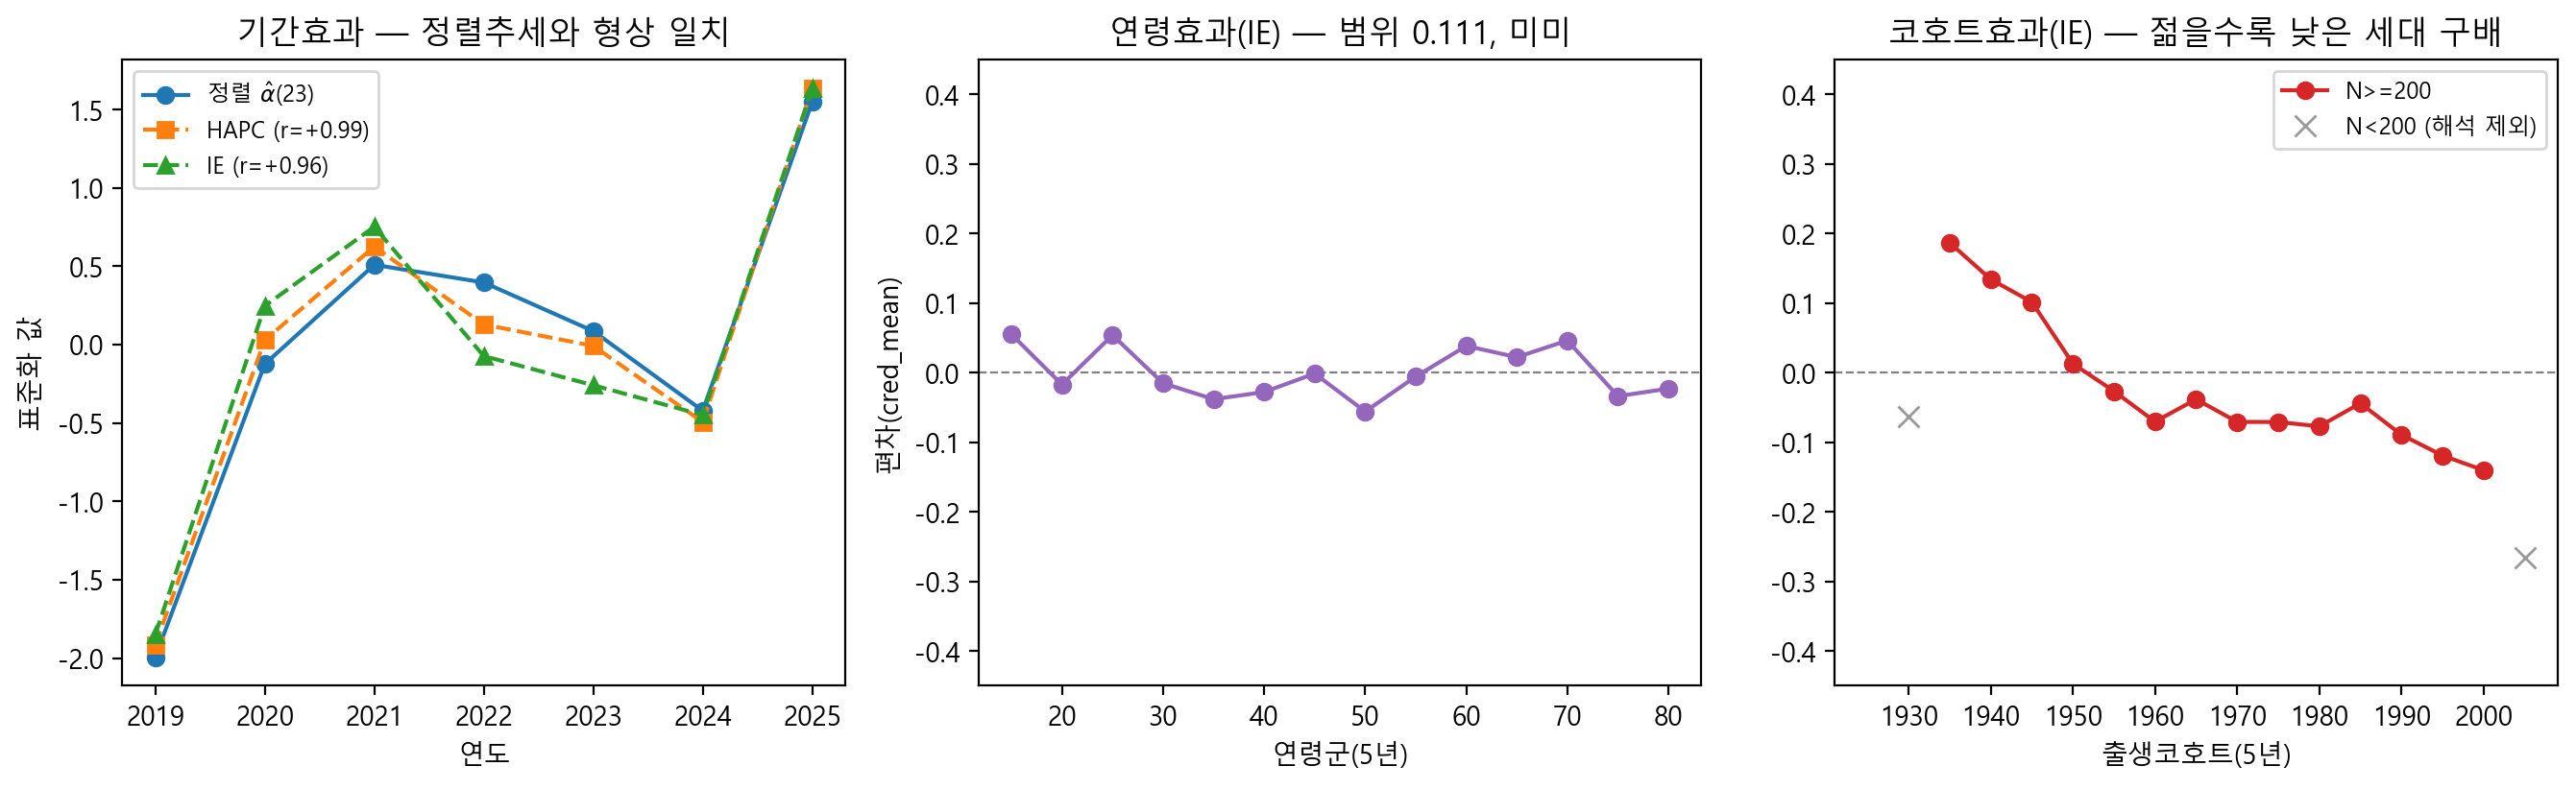

In [3]:
buf = io.StringIO()
with redirect_stdout(buf):
    out4 = X.export_fig4(panel)          # HAPC-GLMM + IE 재적합
log4 = buf.getvalue()
print(log4, end="")

m = re.search(r"HAPC-정렬 = ([+\-][\d.]+) · IE-정렬 = ([+\-][\d.]+)", log4)
R_HAPC_RUN, R_IE_RUN = float(m.group(1)), float(m.group(2))   # 그림 범례 값 — §6 (b)에서 대조
display(Image(str(out4), width=960))

**[시각화] APC 3효과** — **(1)** 기간효과 2종(HAPC·IE)과 정렬추세를 각자 표준화해 겹침(형상 비교), **(2)** 연령효과(IE, 코호트와 동일 스케일로 고정해 '납작함'을 보이게 함), **(3)** 코호트효과(N<200 소표본은 ×로 해석 제외).

**관찰**: 기간효과 두 방법이 정렬추세와 r≥+0.96으로 동행하고(패널 1), 연령효과는 미미하며(패널 2), 코호트는 젊을수록 낮은 구배를 보인다(패널 3) — "상승은 시대의 효과, 세대 구배는 별개의 하방 압력"이라는 보고서 4.4절의 두 문장이 이 한 장에 대응한다.

## **4. [실행] F5 — NCHI 추세 + 페르소나 구성비 (`03` §3·§4 → `assets/fig5_nchi_trend.png`)**

보고서 5.1절의 그림. P6-A 설계가 F5를 "NCHI 추세 + 페르소나 구성비"로 정의했으므로 `03`의 인라인 figure 2개를 좌우 패널로 합본한다(exporter docstring 명기). 신뢰축은 reflective(연도 비교 가능), 다양성·NCHI는 formative — 제목에 "방향성만 해석"을 박아 §3.5 규율을 그림 자체에 새긴다.

[F5] NCHI 연도별 지수 + 페르소나 구성비 산출…


  → 저장: assets\fig5_nchi_trend.png (153 KB)


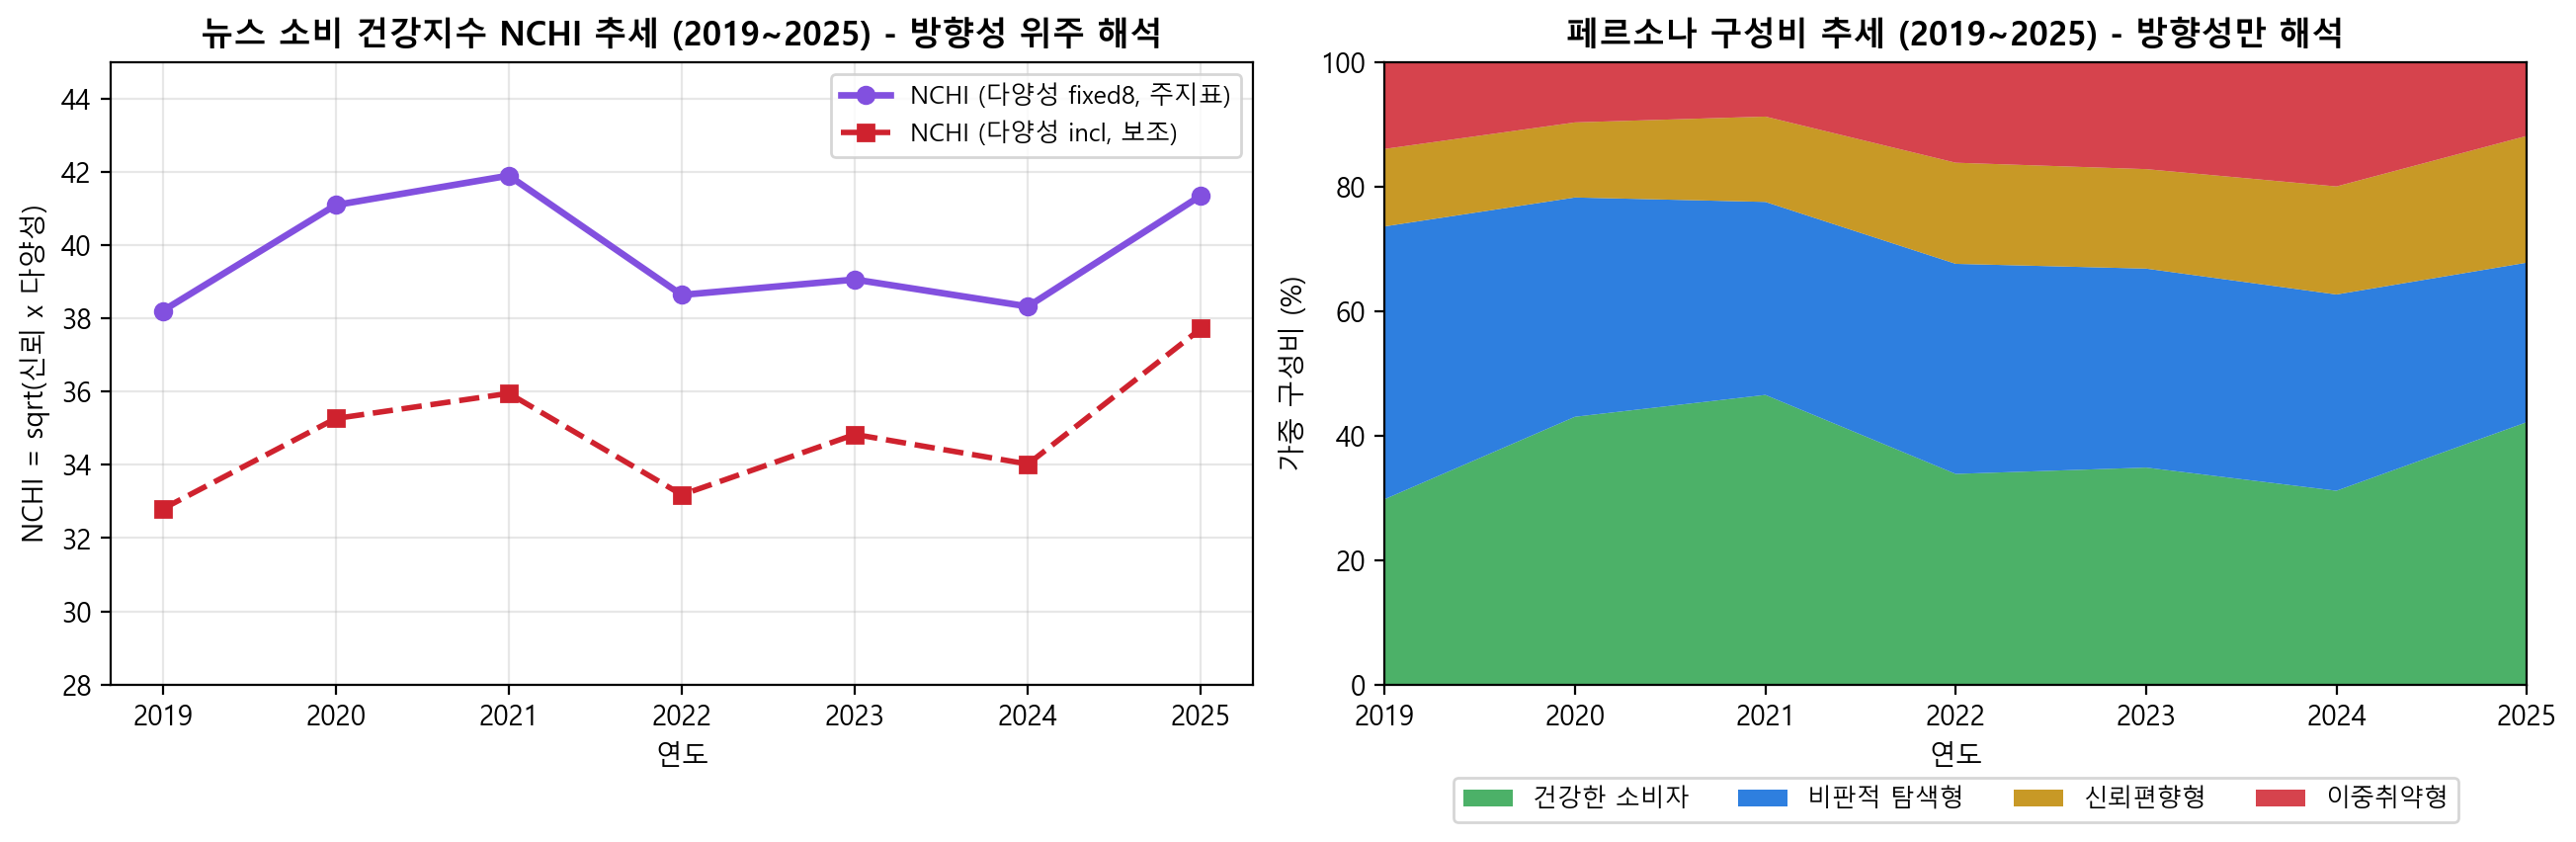

In [4]:
out5 = X.export_fig5(panel)      # NCHI(fixed8·incl) + 페르소나 가중 구성비 재계산
display(Image(str(out5), width=960))

**[시각화] NCHI·구성비** — **(좌)** NCHI 추세: fixed8(주지표, 실선) vs incl(신설매체 포함 보조, 점선). **(우)** 페르소나 4유형 가중 구성비 누적 영역.

**관찰**: NCHI는 신뢰축과 같은 변곡(2024 저점 → 2025 반등)을 보이고, fixed8과 incl의 간격이 "겉보기 다양성 증가는 대부분 매체 목록 추가에서 온다"는 5.1절 서술을 시각화한다. 구성비 패널에서는 신뢰 상승기에 고신뢰층(건강한 소비자+신뢰편향형)이 함께 늘어나는 방향이 보인다 — 절대값이 아니라 **방향**이 이 그림의 주장이다.

## **5. [실행] F6 — 페르소나 × 매체 이용률 히트맵 (`04` §5 → `assets/fig6_personas.png`)**

보고서 5.2절(개입 타깃은 저다양 2유형)의 그림. 규칙 기반 페르소나(신뢰×다양성 4사분면)별로 고정풀 8매체의 **가중 이용률(%)**을 히트맵으로 그린다.

[F6] 페르소나 프로파일(가중 이용률) 산출…


  → 저장: assets\fig6_personas.png (74 KB)


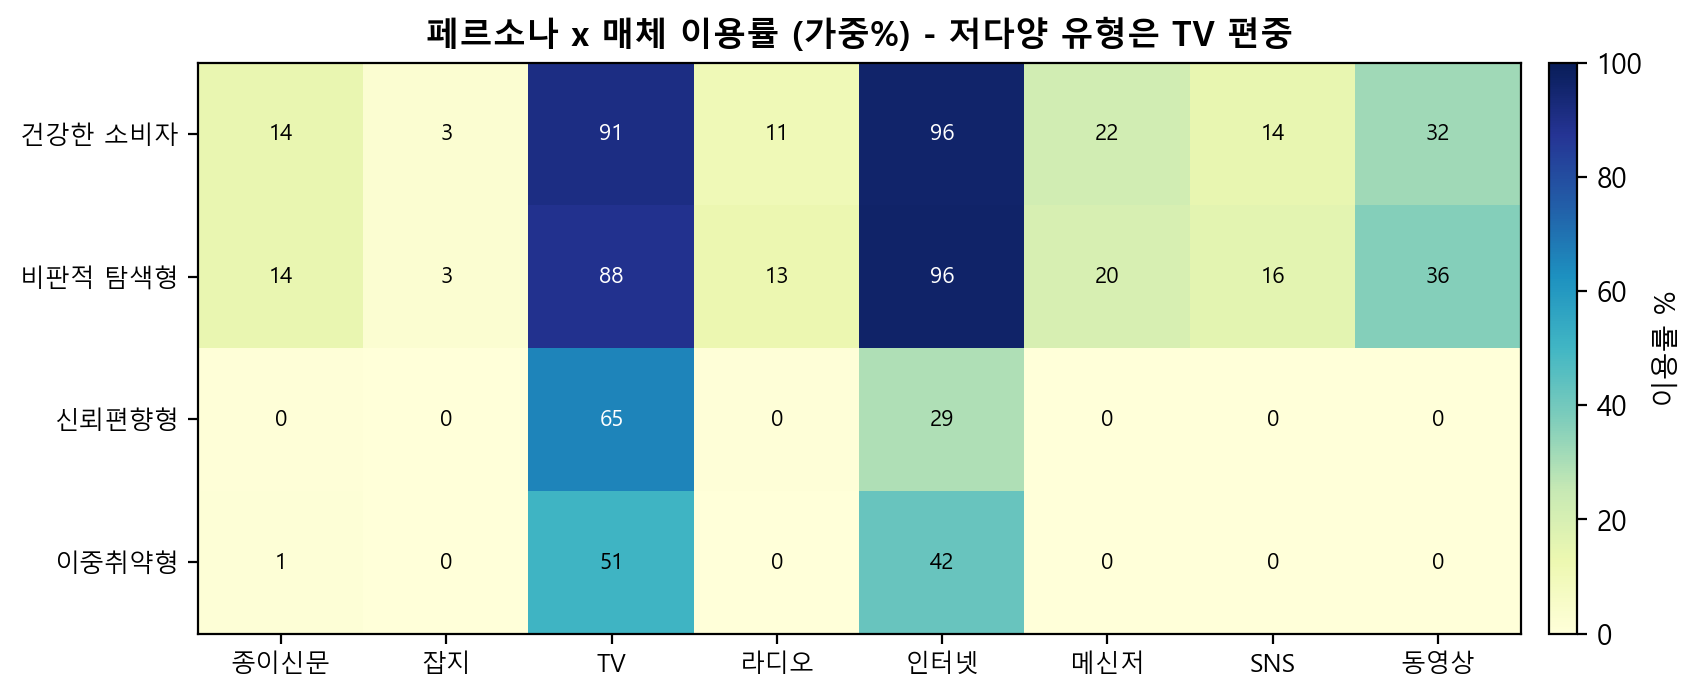

In [5]:
out6 = X.export_fig6(panel)      # 페르소나 × 8매체 가중 이용률 재계산
display(Image(str(out6), width=880))

**[시각화] 페르소나 × 매체 히트맵** — 행: 페르소나 4유형, 열: 고정풀 8매체, 셀: 가중 이용률 %(진할수록 높음).

**관찰**: 고다양 2유형(건강한 소비자·비판적 탐색형)은 TV·인터넷을 축으로 매체 폭이 넓은 반면, **저다양 2유형(신뢰편향형·이중취약형)은 TV 외 매체가 사실상 0에 수렴**한다 — "다양성 노출 확대 개입의 우선 대상"이라는 보고서 7.1절 제안의 근거 그림이다. TV가 두 저다양 유형의 최대 이용 매체라는 사실은 §6 (d)에서 assert로 고정한다.

## **6. [입증] 검증 셀 — figure 수치 ↔ SSOT 상수, drift 없음**

### **Decision Box ② — '같은 그림'의 검증 기준: 왜 픽셀이 아니라 수치인가**

**기준: 재생성된 PNG가 원천 노트북·SSOT와 일치함을 무엇으로 판정하는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 픽셀/바이트 대조 | 기준 PNG와 이미지 diff | ❌ 폰트·matplotlib 버전·렌더러가 바뀌면 내용이 같아도 실패 — 의미 없는 취약성. "그림의 주장"이 아니라 "그림의 물감"을 검사 |
| (b) 파일 존재·크기만 | export가 파일을 만들었는지만 확인 | ❌ 내용 무검증 — 빈 축이 저장돼도 통과 |
| (c) **그림이 담는 수치를 SSOT 상수와 대조** | α̂ 7개년·상관 r·NCHI 방향·TV 편중을 assert | ✅ **채택** — 그림의 **주장**을 검증. `30` §6(상수↔문서)과 이어져 "출처 문서 ↔ 인용 상수 ↔ 보고서 그림"의 사슬이 닫힌다 |

검증 5종: **(a)** F3의 α̂ 7개년 ↔ `ALIGN_ALPHA`(정렬 점추정 재계산, ±0.0015) · **(b)** F4 범례의 r ↔ 상수 재계산 r(±0.01, 둘 다 ≥+0.95) · **(c)** F5의 NCHI 재계산(범위 1~100·2025 반등·신뢰축 2025 최고) + 신뢰축 원천 `cred_mean` 7개년 ↔ `CRED_MEAN`(±0.001) · **(d)** F6의 저다양 2유형 최대 이용 매체 = TV · **(e)** PNG 4종이 이번 실행(T0 이후)에서 재생성·크기 정상.

In [6]:
# (a) F3 ↔ ALIGN_ALPHA — 정렬 점추정 7개년 (부트스트랩 없이 재계산, 그림의 점·주석 값)
yrs, alpha_pts = T.latent_trend_points(panel)
for y, a in zip(yrs.astype(int), alpha_pts):
    ref = P.ALIGN_ALPHA[int(y)]
    assert abs(a - ref) <= 1.5e-3, f"F3 drift: {y} α̂={a:.4f} vs 상수 {ref}"
print("(a) F3 ↔ ALIGN_ALPHA:",
      " ".join(f"{int(y)}={a:+.3f}" for y, a in zip(yrs, alpha_pts)), "— 7개년 전부 일치 PASS")

# (b) F4 범례 r ↔ 상수 재계산 r — 기간효과(HAPC·IE)와 정렬추세의 상관
a_const = np.array([P.ALIGN_ALPHA[y] for y in T.YEARS_ALL])
r_h = np.corrcoef([P.PERIOD_HAPC[y] for y in T.YEARS_ALL], a_const)[0, 1]
r_i = np.corrcoef([P.PERIOD_IE[y] for y in T.YEARS_ALL], a_const)[0, 1]
assert abs(R_HAPC_RUN - r_h) < 0.01 and abs(R_IE_RUN - r_i) < 0.01, "F4 drift: 재적합 r ↔ 상수 r"
assert R_HAPC_RUN >= 0.95 and R_IE_RUN >= 0.95, "F4: 기간효과 동행(r≥+0.96 급) 붕괴"
print(f"(b) F4 r(재적합)={R_HAPC_RUN:+.3f}/{R_IE_RUN:+.3f} ↔ r(상수)={r_h:+.3f}/{r_i:+.3f} — 일치 PASS")

# (c) F5 — NCHI 재계산(방향)과 신뢰축 원천 cred_mean ↔ CRED_MEAN
nchi = hp.nchi_by_year(panel, diversity_version="fixed8")
assert list(nchi.index) == T.YEARS_ALL
v = nchi[["trust_index", "diversity_index", "nchi"]]
assert ((v >= 1) & (v <= 100)).all().all(), "F5: 지수 범위(1~100) 이탈"
assert nchi.loc[2025, "nchi"] > nchi.loc[2024, "nchi"], "F5: 2025 반등(방향) 붕괴"
assert nchi.loc[2025, "trust_index"] == nchi["trust_index"].max(), "F5: 신뢰축 2025 최고 붕괴"
cm3 = panel[hp.CORE3].apply(pd.to_numeric, errors="coerce").mean(axis=1)
cm = T.weighted_year_mean(panel.assign(cred_mean=cm3), "cred_mean", T.YEARS_ALL)
for y, val in zip(T.YEARS_ALL, cm):
    assert abs(val - P.CRED_MEAN[y]) <= 1e-3, f"F5 drift: cred_mean {y} {val:.4f} vs {P.CRED_MEAN[y]}"
print(f"(c) F5 NCHI 방향(2024 {nchi.loc[2024,'nchi']:.1f} → 2025 {nchi.loc[2025,'nchi']:.1f} 반등) + "
      f"cred_mean 7개년 ↔ CRED_MEAN ±0.001 — PASS")

# (d) F6 — 저다양 2유형의 최대 이용 매체 = TV (그림 제목 'TV 편중'의 assert 고정)
W = panel["wt_year_eq"]
T_resp = hp._trust_score_respondent(panel)
D_resp = nf._scale_1_100(pd.to_numeric(panel["richness_fixed8"], errors="coerce"))
persona = nf.persona_quadrant(T_resp, D_resp)
USE8 = ["use_paper", "use_magazine", "use_tv", "use_radio",
        "use_internet", "use_messenger", "use_sns", "use_video"]
for lab in ["신뢰편향형", "이중취약형"]:
    mm = persona == lab
    use = {c: nf.wmean(pd.to_numeric(panel[c], errors="coerce")[mm], W[mm]) * 100 for c in USE8}
    top = max(use, key=use.get)
    assert top == "use_tv", f"F6: {lab} 최대 매체={top} (TV 편중 붕괴)"
    print(f"(d) F6 {lab}: TV {use['use_tv']:.1f}% = 최대 (인터넷 {use['use_internet']:.1f}%) PASS")

# (e) 산출 파일 — 4종 전부 이번 실행에서 재생성·크기 정상
for p in [out3, out4, out5, out6]:
    st = p.stat()
    assert st.st_mtime >= T0, f"{p.name}: 이번 실행 산출이 아님"
    assert st.st_size > 30_000, f"{p.name}: 크기 이상({st.st_size}B)"
print("(e) PNG 4종 재생성 확인(mtime ≥ 실행 시작, >30KB) — PASS")
print(f"\n검증 (a)~(e) 전부 PASS · 총 소요 {time.time()-T0:,.0f}초")

(a) F3 ↔ ALIGN_ALPHA: 2019=+0.000 2020=+0.354 2021=+0.474 2022=+0.453 2023=+0.394 2024=+0.298 2025=+0.671 — 7개년 전부 일치 PASS
(b) F4 r(재적합)=+0.990/+0.960 ↔ r(상수)=+0.990/+0.959 — 일치 PASS
(c) F5 NCHI 방향(2024 38.3 → 2025 41.4 반등) + cred_mean 7개년 ↔ CRED_MEAN ±0.001 — PASS


(d) F6 신뢰편향형: TV 65.5% = 최대 (인터넷 29.0%) PASS
(d) F6 이중취약형: TV 50.7% = 최대 (인터넷 41.9%) PASS
(e) PNG 4종 재생성 확인(mtime ≥ 실행 시작, >30KB) — PASS

검증 (a)~(e) 전부 PASS · 총 소요 169초


**관찰**: (a)에서 F3의 점·주석 값(α̂)이 인용 상수 7개년과 전부 일치하고, (b)에서 방금 재적합한 HAPC·IE의 상관이 상수로 재계산한 상관과 소수 둘째 자리까지 맞물린다 — **그림은 저장본의 재탕이 아니라 재계산 산출이며, 그 재계산이 SSOT와 어긋나지 않는다**. (c)·(d)는 formative 규율(방향만)에 맞춰 절대값이 아닌 방향·순위를 고정했고, (e)는 파일 자체의 신선도를 봉인한다. `30` §6(상수↔출처 문서, 34개 수치 무drift)과 합치면: **출처 문서 ↔ 인용 상수 ↔ 보고서 그림**의 3단 사슬이 전부 assert로 닫혔다.

## **7. 종합 — P6-B figure export가 입증됐다**

### **연구질문 답**

- **Q1 (재현 가능한 산출인가)** — 그렇다. `src/export_figures.py`의 exporter 4종을 본 노트북이 순서대로 호출해 `assets/fig3~fig6` PNG가 전부 재생성됐다(§2~§5 실행 출력·§6(e) mtime 검증). 재현 명령은 `python src/export_figures.py` 한 줄이다.
- **Q2 (SSOT와 drift 없는가)** — 그렇다. F3의 α̂ 7개년 = `ALIGN_ALPHA` 전값 일치, F4의 기간효과 상관(재적합 +0.99/+0.96)이 상수 재계산과 일치, F5의 신뢰축 원천 `cred_mean` 7개년 = `CRED_MEAN` ±0.001, F6의 "저다양 2유형 TV 편중"이 가중 이용률 순위로 고정 — §6 (a)~(e) 전부 PASS.
- **Q3 (왜 별도 스크립트·무엇으로 검증)** — 노트북 오염 없는 1명령 재현을 위해 export를 스크립트로 분리하고(DB①), 검증은 픽셀이 아니라 **그림이 담는 수치의 SSOT 대조**로 한다(DB②). 이로써 `30` §6과 연결된 "문서 ↔ 상수 ↔ 그림" 검증 사슬이 완성됐다.

### **단계 요약**

| § | 한 일 | 산출 · 판정 |
|---|------|------------|
| 1 | export 방식 설계 근거(DB①) | 별도 스크립트 채택 |
| 2 | F3 재생성(정렬 주모형 B=200 재실행) | `fig3_alignment_trend.png` |
| 3 | F4 재생성(HAPC·IE 재적합, 범례 r 캡처) | `fig4_apc_profile.png` |
| 4 | F5 재생성(NCHI fixed8·incl + 구성비 합본) | `fig5_nchi_trend.png` |
| 5 | F6 재생성(페르소나 × 8매체 가중 이용률) | `fig6_personas.png` |
| 6 | SSOT drift 검증 5종(DB②) | **(a)~(e) 전부 PASS** |

### **다음**

- **P6-B-3 조판**: 이 4종 + 기존 F2·F7·F8을 참조하는 `docs/report/manuscript.md`를 **md → HTML(논문형 CSS) → headless Chrome PDF**로 조판해 `dist/report.pdf`(15p 이내)를 산출한다(`p6-pdf-structure.md` §6 B-3).
- **F9(웹데모 스크린샷)**: 웹데모 구현 후 최종 리비전에서 삽입.